redo of q6 on hw2 where we get full points wrong...

# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import beta as scipy_beta


In [2]:
# Override ugly matplotlib defaults
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
    "font.size": 12,
})


In [3]:
# defining the givens from the problem...
fixed_prior = .01 
fixed_sensitivity = .95
fixed_specificity = .90

Using Bayes' Rule, we can get obtain the formula for calculating the posterior given the prior, sensitivity, and specificity.

Mathematically,
\begin{align*}
P(\text{disease} \mid \text{positive}) 
& = \frac{P(\text{positive}) \mid P(\text{disease}) P(\text{disease})}{P(\text{positive})} \\ 
& = \frac{P(\text{positive}) \mid P(\text{disease}) P(\text{disease}) }
{P(\text{positive} \mid \text{disease}) P(\text{disease}) 
+ 
P(\text{positive} \mid \overline{\text{disease}})P(\overline{\text{disease}})}
\end{align*}

Then, using the scenario of the problem, we can symbolically formulate it as such:
$$
P(\mathrm{disease} \mid \mathrm{positive}) 
= \frac{\mathrm{sensitivity} \cdot \mathrm{prior}}{\mathrm{sensitivity} \cdot \mathrm{prior} + (1 - \mathrm{specificity})(1 - \mathrm{prior})}
$$ 


In [5]:
def calculate_posterior(prior, sensitivity, specificity):
    num = sensitivity * prior
    denom = num + (1.0 - specificity) * (1.0 - prior)

    return num / denom

In [6]:
fixed_posterior = calculate_posterior(fixed_prior, fixed_sensitivity, fixed_specificity)
print(f"posterior with the given fixed parameters is {fixed_posterior:.4f}")

posterior with the given fixed parameters is 0.0876


# 1... fixed sensitivty and specficiity, vary prior

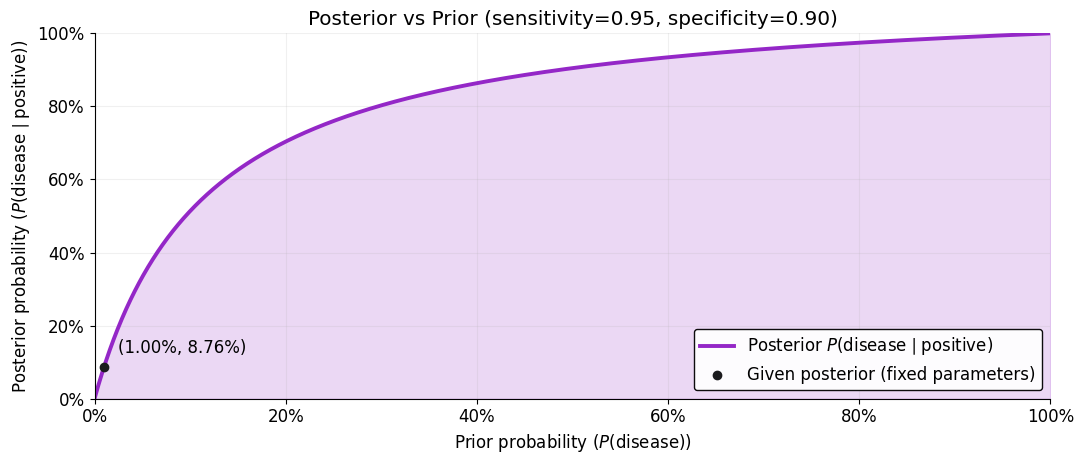

In [7]:
prior_domain = np.linspace(1e-4, 1 - 1e-4, 2000)
posterior_varied_prior = calculate_posterior(prior_domain, fixed_sensitivity, fixed_specificity)


# plotting...
fig, ax = plt.subplots(figsize=(11, 4.8))
curve_color = "#9427C7"
base_color  = "#1B1B1E"

ax.plot(prior_domain, posterior_varied_prior, lw=2.8, color=curve_color,
        label=r"Posterior $P(\text{disease} \mid \text{positive})$")
ax.fill_between(prior_domain, 0, posterior_varied_prior, color=curve_color, alpha=0.18)

ax.scatter([fixed_prior], [fixed_posterior], color=base_color, zorder=5, label="Given posterior (fixed parameters)")
ax.annotate(f"({fixed_prior:.2%}, {fixed_posterior:.2%})",
            (fixed_prior, fixed_posterior), textcoords="offset points", xytext=(10, 10))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"Prior probability ($P(\text{disease})$)")
ax.set_ylabel(r"Posterior probability ($P(\text{disease} \mid \text{positive})$)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Posterior vs Prior (sensitivity={fixed_sensitivity:.2f}, specificity={fixed_specificity:.2f})")
ax.legend(frameon=True, framealpha=0.95, facecolor="white", edgecolor=(0, 0, 0, 0.12))

fig.tight_layout()

# 2... fixed prior and specficiity, vary sensitivity

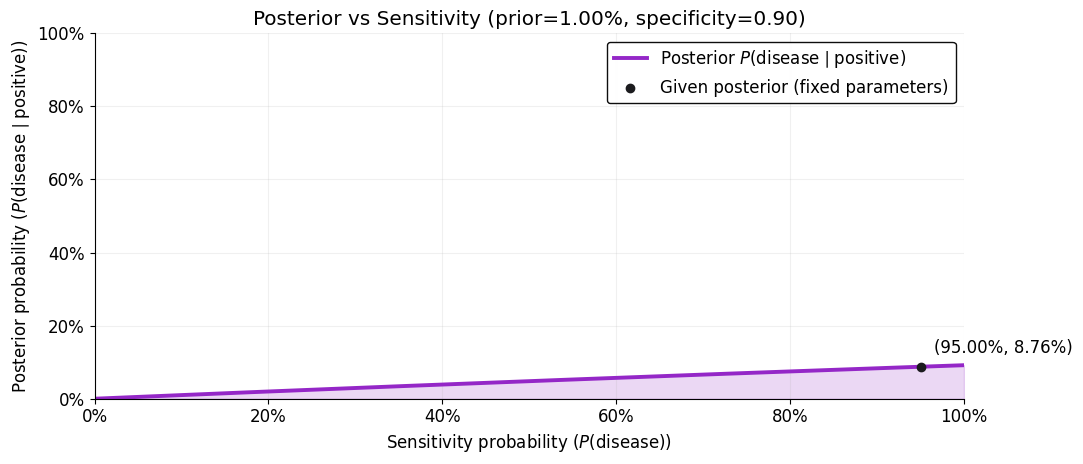

In [8]:
sensitivity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
post_vs_sens = calculate_posterior(fixed_prior, sensitivity_domain, fixed_specificity)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(sensitivity_domain, post_vs_sens, lw=2.8, color=curve_color,
        label=r"Posterior $P(\text{disease} \mid \text{positive})$")
ax.fill_between(sensitivity_domain, 0, post_vs_sens, color=curve_color, alpha=0.18)

ax.scatter([fixed_sensitivity], [fixed_posterior], color=base_color, zorder=5, label="Given posterior (fixed parameters)")
ax.annotate(f"({fixed_sensitivity:.2%}, {fixed_posterior:.2%})",
            (fixed_sensitivity, fixed_posterior), textcoords="offset points", xytext=(10, 10))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"Sensitivity probability ($P(\text{disease})$)")
ax.set_ylabel(r"Posterior probability ($P(\text{disease} \mid \text{positive})$)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Posterior vs Sensitivity (prior={fixed_prior:.2%}, specificity={fixed_specificity:.2f})")
ax.legend(frameon=True, framealpha=0.95, facecolor="white", edgecolor=(0, 0, 0, 0.12))

fig.tight_layout()

# 3... fixed prior and sensitivity, vary specificity

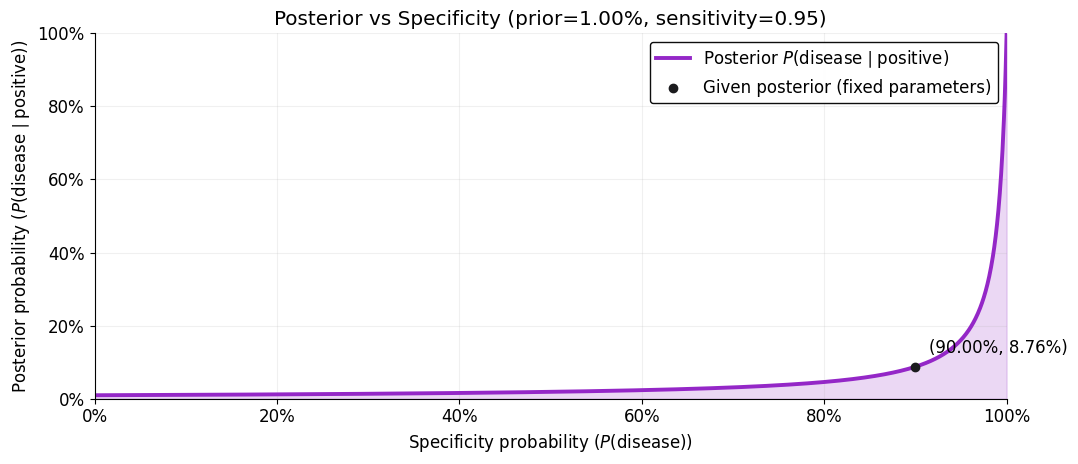

In [10]:
specificity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
posterior_varied_specificity = calculate_posterior(fixed_prior, fixed_sensitivity, specificity_domain)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(specificity_domain, posterior_varied_specificity, lw=2.8, color=curve_color,
        label=r"Posterior $P(\text{disease} \mid \text{positive})$")
ax.fill_between(specificity_domain, 0, posterior_varied_specificity, color=curve_color, alpha=0.18)

ax.scatter([fixed_specificity], [fixed_posterior], color=base_color, zorder=5, label="Given posterior (fixed parameters)")
ax.annotate(f"({fixed_specificity:.2%}, {fixed_posterior:.2%})",
            (fixed_specificity, fixed_posterior), textcoords="offset points", xytext=(10, 10))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"Specificity probability ($P(\text{disease})$)")
ax.set_ylabel(r"Posterior probability ($P(\text{disease} \mid \text{positive})$)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Posterior vs Specificity (prior={fixed_prior:.2%}, sensitivity={fixed_sensitivity:.2f})")
ax.legend(frameon=True, framealpha=0.95, facecolor="white", edgecolor=(0, 0, 0, 0.12))

fig.tight_layout()

# Bonus

## prior - sensitivity


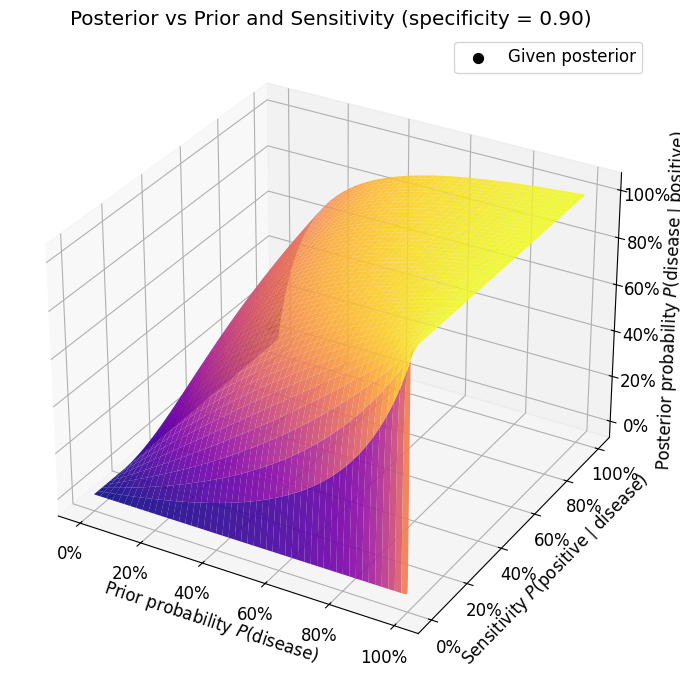

In [19]:
prior_domain = np.linspace(1e-4, 1 - 1e-4, 2000)
sensitivity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
fixed_specificity = .90


P, S = np.meshgrid(prior_domain, sensitivity_domain)
Z1 = calculate_posterior(P, S, fixed_specificity)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(P, S, Z1, cmap='plasma', alpha=0.9)

# baseline point
z_fixed = calculate_posterior(fixed_prior, fixed_sensitivity, fixed_specificity)
ax.scatter(fixed_prior, fixed_sensitivity, z_fixed, color='black', s=50, label='Given posterior')

ax.set_title('Posterior vs Prior and Sensitivity (specificity = 0.90)')
ax.set_xlabel(r'Prior probability $P(\text{disease})$')
ax.set_ylabel(r'Sensitivity $P(\text{positive} \mid \text{disease})$')
ax.set_zlabel(r'Posterior probability $P(\text{disease} \mid \text{positive})$')

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.zaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend()
plt.tight_layout()
plt.show()


## prior - specificity


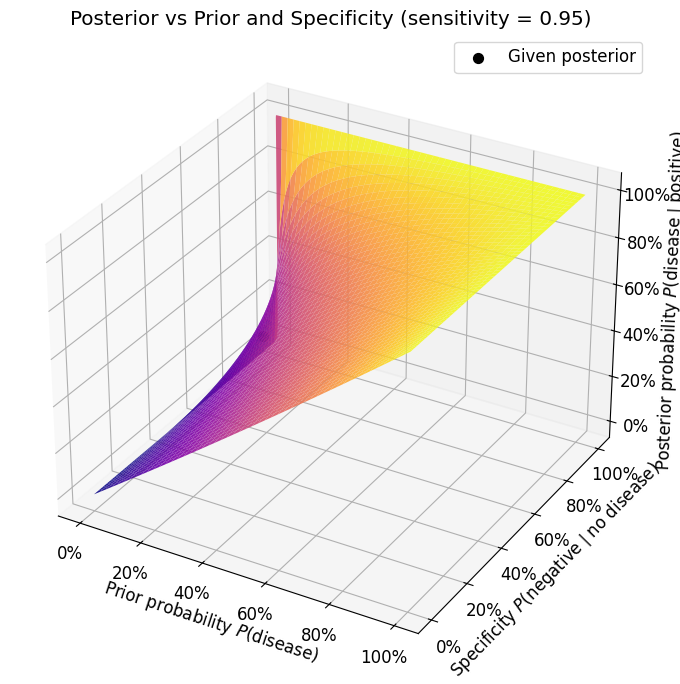

In [16]:
prior_domain = np.linspace(1e-4, 1 - 1e-4, 2000)
specificity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
fixed_sensitivity = .95


P, C = np.meshgrid(prior_domain, specificity_domain)
Z2 = calculate_posterior(P, fixed_sensitivity, C)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(P, C, Z2, cmap='plasma', alpha=0.9)

ax.scatter(fixed_prior, fixed_specificity, z_fixed, color='black', s=50, label='Given posterior')

ax.set_title('Posterior vs Prior and Specificity (sensitivity = 0.95)')
ax.set_xlabel(r'Prior probability $P(\text{disease})$')
ax.set_ylabel(r'Specificity $P(\text{negative} \mid \text{no disease})$')
ax.set_zlabel(r'Posterior probability $P(\text{disease} \mid \text{positive})$')

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.zaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend()
plt.tight_layout()
plt.show()

## sensitivity - specificity

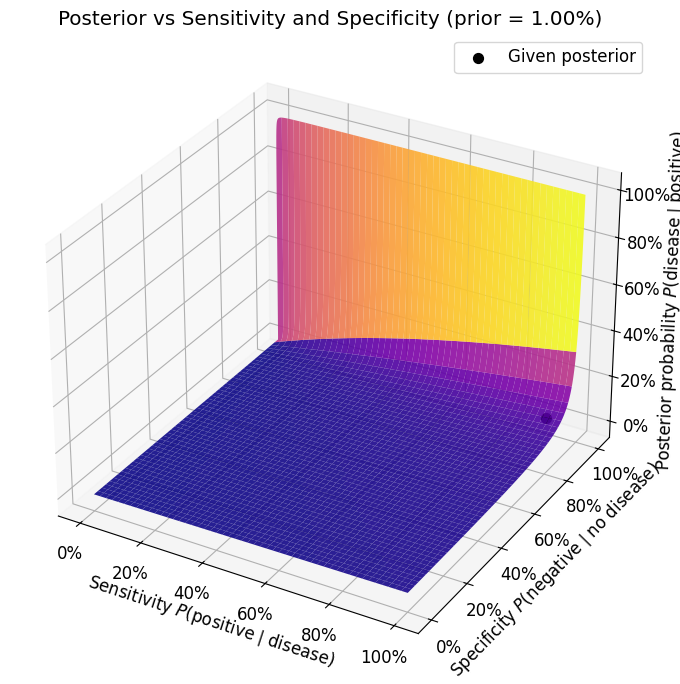

In [17]:
sensitivity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
specificity_domain = np.linspace(1e-6, 1 - 1e-6, 2000)
fixed_prior = .01


S, C = np.meshgrid(sensitivity_domain, specificity_domain)
Z3 = calculate_posterior(fixed_prior, S, C)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(S, C, Z3, cmap='plasma', alpha=0.9)

ax.scatter(fixed_sensitivity, fixed_specificity, z_fixed, color='black', s=50, label='Given posterior')

ax.set_title('Posterior vs Sensitivity and Specificity (prior = 1.00%)')
ax.set_xlabel(r'Sensitivity $P(\text{positive} \mid \text{disease})$')
ax.set_ylabel(r'Specificity $P(\text{negative} \mid \text{no disease})$')
ax.set_zlabel(r'Posterior probability $P(\text{disease} \mid \text{positive})$')

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.zaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend()
plt.tight_layout()
plt.show()